In [1]:
import numpy as np
import torch
import pandas as pd

from pmbrl.model import *
from pmbrl.data import *


In [2]:
params = {
    "mode": "all",
    "n":100,
    "num_epochs": 5000,
    "learning_rate": 0.001
}

In [3]:
hist_s, hist_a, hist_p = generate_hist(n=params['n'])

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


In [4]:
X_train, y_train, X_test, y_test = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'])

m = Model(learning_rate=params['learning_rate'])
m.train(X_train, y_train, num_epochs=params['num_epochs'], debug=False, mode=params['mode'])
print('RMSE: ', torch.mean((m.predict(X_test, mode=params['mode']) - y_test)**2, axis=0)**.5)

RMSE:  tensor([0.0221, 0.1050])


In [5]:
params['mode'] = 'param'

X_train, y_train, X_test, y_test = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'])

m = Model(learning_rate=params['learning_rate'])
m.train(X_train, y_train, num_epochs=params['num_epochs'], debug=False, mode=params['mode'])
print('RMSE: ', torch.mean((m.predict(X_test, mode=params['mode']) - y_test)**2, axis=0)**.5)

RMSE:  tensor([0.0148, 0.2457])


# Param

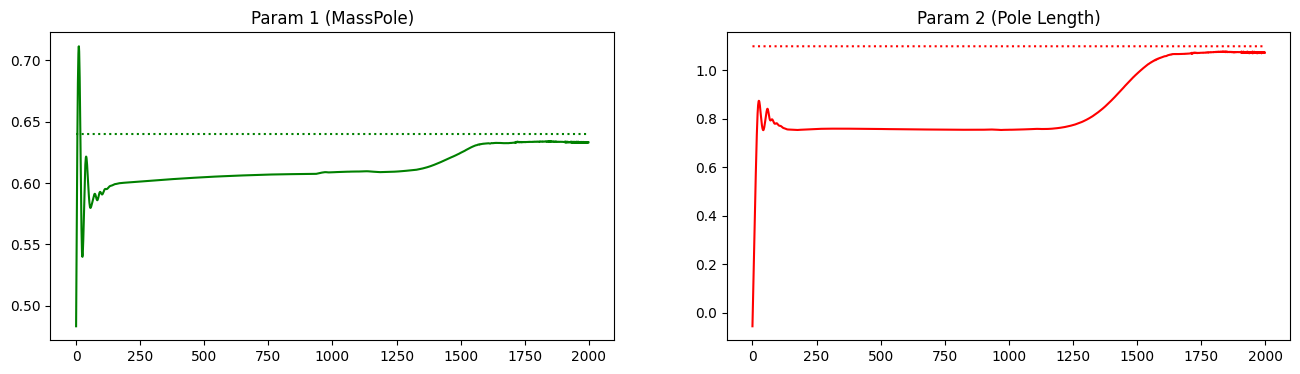

In [6]:
import matplotlib.pyplot as plt
import numpy as np


params = {
    "mode": "param",
    "n":100,
    "num_epochs": 2000,
    "learning_rate": 0.01
}

X_train, y_train, _, _ = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'], p=0)
m = Model(learning_rate=params['learning_rate'])
def iterate():
    m.train(X_train[:-1], y_train[:-1], num_epochs=1, debug=False, mode=params['mode'])
    return m.predict(X_train[-1:], mode=params['mode'])


lines = np.array([iterate() for epoch in range(params['num_epochs'])])
reff = np.array([y_train[-1:] for epoch in range(params['num_epochs'])])


fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(lines[:,:,0], color = 'g')
axs[0].plot(reff[:,:,0], linestyle = 'dotted', color = 'g')
axs[0].set_title('Param 1 (MassPole)')
# axs[0].legend()

axs[1].plot(lines[:,:,1], color = 'r')
axs[1].plot(reff[:,:,1], linestyle = 'dotted', color = 'r')
axs[1].set_title('Param 2 (Pole Length)')

plt.show()

# State

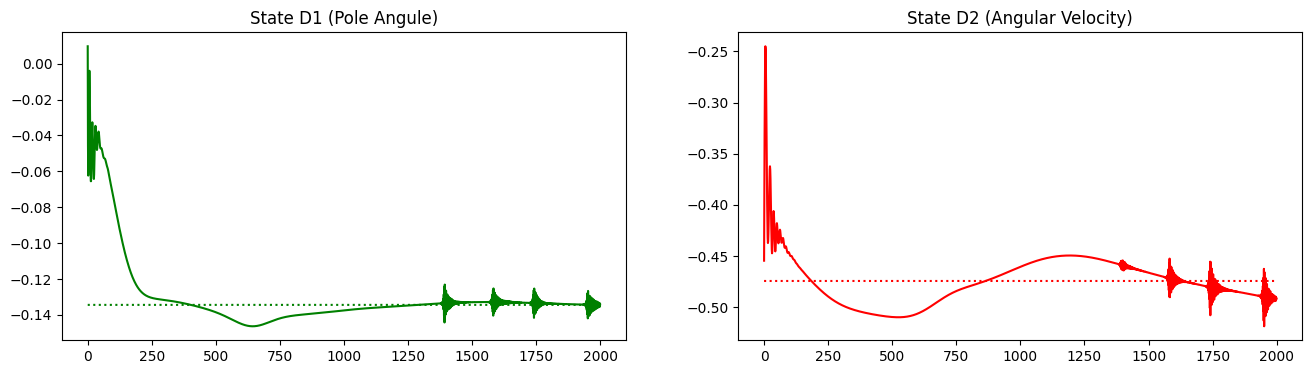

In [7]:
import matplotlib.pyplot as plt
import numpy as np


params = {
    "mode": "state",
    "n":100,
    "num_epochs": 2000,
    "learning_rate": 0.01
}

X_train, y_train, _, _ = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'], p=0)
m = Model(learning_rate=params['learning_rate'])
def iterate():
    m.train(X_train[:-1], y_train[:-1], num_epochs=1, debug=False, mode=params['mode'])
    return m.predict(X_train[-1:], mode=params['mode'])


lines = np.array([iterate() for epoch in range(params['num_epochs'])])
reff = np.array([y_train[-1:] for epoch in range(params['num_epochs'])])


fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(lines[:,:,0], color = 'g')
axs[0].plot(reff[:,:,0], linestyle = 'dotted', color = 'g')
axs[0].set_title('State D1 (Pole Angule)')
# axs[0].legend()

axs[1].plot(lines[:,:,1], color = 'r')
axs[1].plot(reff[:,:,1], linestyle = 'dotted', color = 'r')
axs[1].set_title('State D2 (Angular Velocity)')

plt.show()

# All

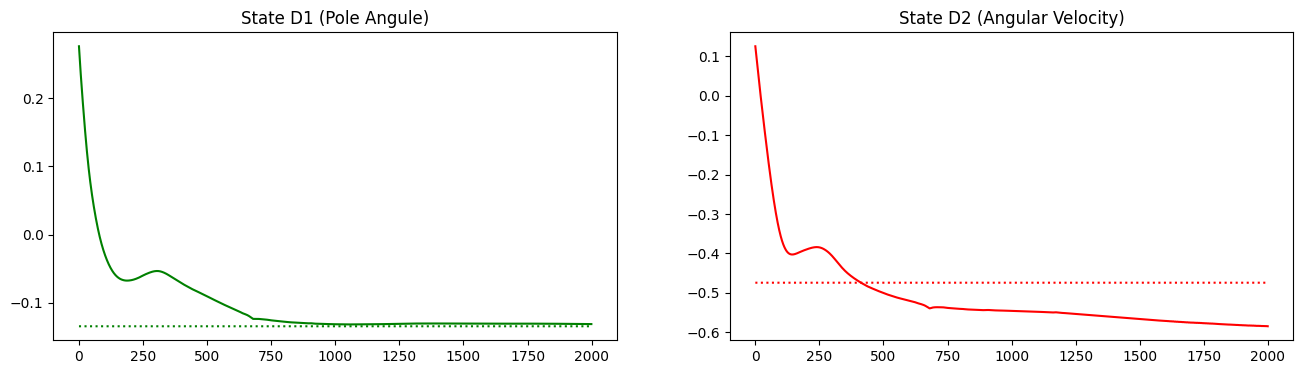

In [8]:
import matplotlib.pyplot as plt
import numpy as np


params = {
    "mode": "all",
    "n":100,
    "num_epochs": 2000,
    "learning_rate": 0.001
}

X_train, y_train, _, _ = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'], p=0)
m = Model(learning_rate=params['learning_rate'])
def iterate():
    m.train(X_train[:-1], y_train[:-1], num_epochs=1, debug=False, mode=params['mode'])
    return m.predict(X_train[-1:], mode=params['mode'])


lines = np.array([iterate() for epoch in range(params['num_epochs'])])
reff = np.array([y_train[-1:] for epoch in range(params['num_epochs'])])


fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(lines[:,:,0], color = 'g')
axs[0].plot(reff[:,:,0], linestyle = 'dotted', color = 'g')
axs[0].set_title('State D1 (Pole Angule)')
# axs[0].legend()

axs[1].plot(lines[:,:,1], color = 'r')
axs[1].plot(reff[:,:,1], linestyle = 'dotted', color = 'r')
axs[1].set_title('State D2 (Angular Velocity)')

plt.show()